# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Modelo BERT

Objetivo: apresentar o funcionamento do Modelo BERT para geração de Word Embeddings.

Você vai aprender a:
- Pré-processar textos usando um tokenizador
- Entender as entradas e as saídas do modelo
- Extrair os word embeddings gerados pelo modelo

Referências: <br>
https://arxiv.org/abs/1810.04805 <br>
https://medium.com/@dhartidhami/understanding-bert-word-embeddings-7dc4d2ea54ca <br>
http://jalammar.github.io/illustrated-bert/ <br>
https://huggingface.co/course/chapter1/1 

Versão: Dezembro, 2022

## Pacotes

In [1]:
import numpy as np # scientific computing
import tensorflow as tf  #  numerical computation using data flow graphs
from transformers import BertTokenizer, TFBertModel  # Hugging Face Transformer API

2024-04-28 12:11:16.505910: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-28 12:11:16.546048: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-28 12:11:16.546078: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-28 12:11:16.546110: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-28 12:11:16.552821: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-04-28 12:11:16.553578: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

## Tokenização e Word Embedding

Modelos Transformer, como em outras redes neurais, não podem processar textos diretamente. Assim, o primeiro passo é converter os textos de entrada em números que façam sentido para o modelo. Para fazer isso, nós usamos um tokenizador, o qual é responsável por:
- Dividir a entrada em palavras, subpalavras, or símbolos (como pontuação), que são chamados de tokens.
- Mapear cada token para um número inteiro
- Adicionar outras entradas que podem ser úteis para o modelo

No código abaixo, foram adicionados à sentença de entrada os seguintes códigos específicos do modelo BERT:
- [CLS]: token de classificação binária, adicionado no início da primeira sentença para predizer se a segunda sentença segue a primeira. É necessário adicioná-lo mesmo para entradas compostas por uma única sentença.
- [SEP]: token de separação que sinaliza o fim de uma sequência.

Na tokenização, observe que uma palavra pode ser dividida em subpalavras menores e caracteres. Exemplo, a palavra 'Sentença' foi dividida em: <br>
['Sent', '##en', '##ça']

Isso acontece porque o vocabulário BERT tem um tamanho fixo de aproximadamente 120 mil tokens para a versão multilinguagem (104 idiomas) e 30 mil para o inglês. Palavras que não são parte do vocabulário são representadas com subpalavras e caracteres.

O tokenizador recebe como entrada uma sentença e decide manter a palavra inteira, dividí-la em subpalavras (com representação especial da primeira subpalavra e subpalavras subsequentes usando o símbolo ##) ou como último recurso decompor a palavra em caracteres individuais. Por causa disso, todas as palavras possuem uma representação, em último caso, como uma coleção de caracteres individuais.

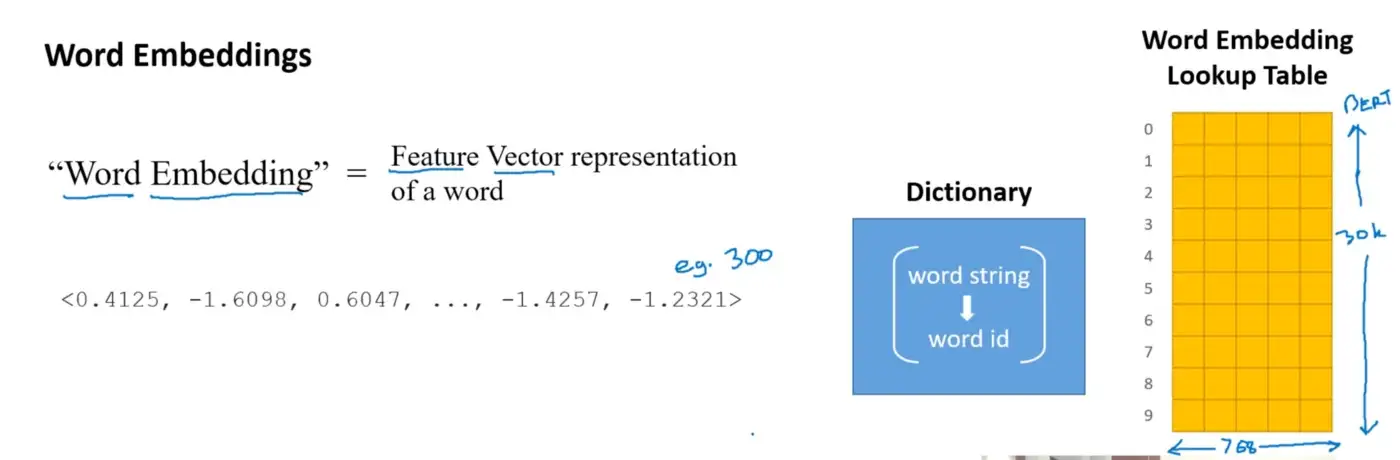
https://medium.com/@dhartidhami/understanding-bert-word-embeddings-7dc4d2ea54ca

In [2]:
# Indica o modelo BERT pré-treinado
checkpoint = "bert-base-multilingual-cased" # BERT base multilinguagem (incluindo o português) com tokens não convertidos para minúsculas
# Tokenizador para o qual o modelo foi treinado
tokenizer = BertTokenizer.from_pretrained(checkpoint)
# Texto de exemplo
text = "Sentença a ser tokenizada"
# Adiciona tokens [CLS]  e [SEP]
marked_text = "[CLS] " + text + " [SEP]"
# Tokeniza a sentença com o BERT tokenizer
tokenized_text = tokenizer.tokenize(marked_text)
# Imprime os tokens
print (tokenized_text)

['[CLS]', 'Sent', '##en', '##ça', 'a', 'ser', 'tok', '##eni', '##zada', '[SEP]']


Seguem alguns exemplos dos tokens contidos no vocabulário. Como estamos usando um modelo multilinguagem, os tokens estão em idiomas diversos.

In [3]:
list(tokenizer.vocab.keys())[50000:50020]

['héros',
 'особено',
 'Championnats',
 '1576',
 'occitana',
 'spoke',
 '##ạo',
 'exclusive',
 'Републике',
 'ফুট',
 '##ovej',
 'servizi',
 '##ація',
 'Programa',
 '##zno',
 '##häuser',
 '##ídos',
 '##צד',
 '##ობით',
 'toku']

### Índice no vocabulário (Token ID)
Cada token é representado numericamente por seu índice no vocabulário (token id).<br>
Observe no código abaixo que as palavras "banco" possuem, inicialmente, o mesmo índice no vocabulário, independentemente do seu contexto. Posteriormente, o seu embedding terá representações diferentes.

In [4]:
# Sentença com significados diferentes para a palavra "banco"
text = "Após ir ao banco pedir um empréstimo, Maria sentou-se no banco da praça."
# Adiciona os tokens especiais
marked_text = "[CLS] " + text + " [SEP]"
# Divide a sentença em tokens
tokenized_text = tokenizer.tokenize(marked_text)
# Mapeia as strings dos tokens para seus índices no vocabulário
indexed_tokens = tokenizer.convert_tokens_to_ids(tokenized_text)
# Mostra as palavras e seus índices
for tup in zip(tokenized_text, indexed_tokens):
    print('{:<12} {:>6,}'.format(tup[0], tup[1]))

[CLS]           101
Após         23,906
ir           10,478
ao           10,610
banco        55,379
pe           11,161
##dir        11,957
um           10,293
em           10,266
##pr         52,302
##ést        27,584
##imo        15,487
,               117
Maria        11,066
sent         14,541
##ou         11,010
-               118
se           10,126
no           10,192
banco        55,379
da           10,143
pra          69,857
##ça         12,989
.               119
[SEP]           102


No processo inverso, os ids dos tokens podem ser convertidos de volta nas strings originais.

In [5]:
print("IDs dos tokens: ", indexed_tokens, "\n")
decoded_string = tokenizer.decode(indexed_tokens)
print("Sentença original: ", decoded_string)

IDs dos tokens:  [101, 23906, 10478, 10610, 55379, 11161, 11957, 10293, 10266, 52302, 27584, 15487, 117, 11066, 14541, 11010, 118, 10126, 10192, 55379, 10143, 69857, 12989, 119, 102] 

Sentença original:  [CLS] Após ir ao banco pedir um empréstimo, Maria sentou - se no banco da praça. [SEP]


### input_ids, token_type_ids e attention_mask
A entrada para o modelo é na forma de um dicionário contendo códigos para as seguintes chaves: identificadores dos tokens de entrada (input_ids), tipos dos ids dos tokens (token_type_ids) e máscaras de atenção (attention_mask).<br>
O construtor "tokenizer" retorna a sentença tokenizada, com os códigos [CLS] e [SEP] já adicionados à entrada ("input_ids"). Além disso, o dicionário da entrada inclui também os "token_type_ids" e as "attention_mask".<br>
input_ids: índice no dicionário para cada token.<br>
token_type_ids: zero para cada token da primeira sentença e um cada cada token da segunda sentença. No caso de somente uma sentença, todas as entradas são preenchidas com zero.<br>
attention_mask: um para cada token da sentença que merece atenção e zero para os demais tokens a serem ignorados (tokens padding, por exemplo).

In [6]:
inputs = tokenizer(text)
print(inputs)

{'input_ids': [101, 23906, 10478, 10610, 55379, 11161, 11957, 10293, 10266, 52302, 27584, 15487, 117, 11066, 14541, 11010, 118, 10126, 10192, 55379, 10143, 69857, 12989, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Para especificar o tipo de tensor a ser retornado pelo "tokenizer", use o argumento "return_tensors": pt = PyTorch, tf = TensorFlow, or np = NumPy.

In [7]:
inputs = tokenizer(text, return_tensors="tf")
print(inputs)

{'input_ids': <tf.Tensor: shape=(1, 25), dtype=int32, numpy=
array([[  101, 23906, 10478, 10610, 55379, 11161, 11957, 10293, 10266,
        52302, 27584, 15487,   117, 11066, 14541, 11010,   118, 10126,
        10192, 55379, 10143, 69857, 12989,   119,   102]], dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(1, 25), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(1, 25), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1]], dtype=int32)>}


2024-04-28 12:11:50.262109: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-04-28 12:11:50.264539: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


### Padding
O modelo espera um lote (batch) de entradas, na forma de lista. As sentenças de entrada podem ter tamanhos diferentes. Porém, os tensores precisam estar em um formato retangular. Assim, as entradas menores precisam ser preenchidas (padded) com um token especial (padding token) para ficarem com o mesmo tamanho.

### Truncate
Com os modelos Transformers, há um limite para o comprimento das sentenças que podem ser passadas para os modelos. A maioria dos modelos lida com até 512 ou 1024 tokens. Uma forma de tratar com sentenças mais longas é truncá-las para o comprimento que o modelo aceita. O parâmetro "max_sequence_length" pode ser usado para isso.

In [8]:
sentencas = ["Primeira sentença.", "Segunda sentença com um comprimento maior"]
inputs = tokenizer(sentencas, padding=True, truncation=True, return_tensors="tf")
print(inputs)
# Observe que a primeira sentença foi preenchida com zeros para ter o mesmo número de tokens da segunda.
# Observe também que 'attention_mask' recebe zero para as posições do padding.

{'input_ids': <tf.Tensor: shape=(2, 9), dtype=int32, numpy=
array([[  101, 41478, 97705, 21050,   119,   102,     0,     0,     0],
       [  101, 16843, 97705, 21050, 10212, 10293, 73355, 14844,   102]],
      dtype=int32)>, 'token_type_ids': <tf.Tensor: shape=(2, 9), dtype=int32, numpy=
array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(2, 9), dtype=int32, numpy=
array([[1, 1, 1, 1, 1, 1, 0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1]], dtype=int32)>}


## Entendendo a Saída do Modelo
A arquitetura base do módulo Transformer retorna como saída os "hidden states" (estados ocultos), também conhecidos como features.<br>
O vetor de saída tem três dimensões:
- Batch size: o número de sequências de entrada processadas de cada vez
- Sequence length: o comprimento da representação numérica das sequências de entrada
- Hidden size: a dimensão do vetor de cada entrada do modelo. Pode ser de tamanho 768 para os modelos menores, e chegar a 3072 ou mais para os modelos maiores.

O modelo retorna por padrão o estado oculto da última camada encoder ("last_hidden_state"). O modelo que estamos usando tem 12 camadas + 1 camada para o embedding de entrada. Para acessar cada camada, usamos o elemento "hidden_states", o qual retorna uma tupla onde cada posição representa o estado oculto de uma das camadas. A posição 12 é a última camada (o mesmo que "last_hidden_state"), a posição 11 é a penúltima camada, e assim por diante, até a posição 0, que é camada de embedding de entrada.

Documentação: https://huggingface.co/docs/transformers/v4.25.1/en/model_doc/bert#transformers.TFBertModel

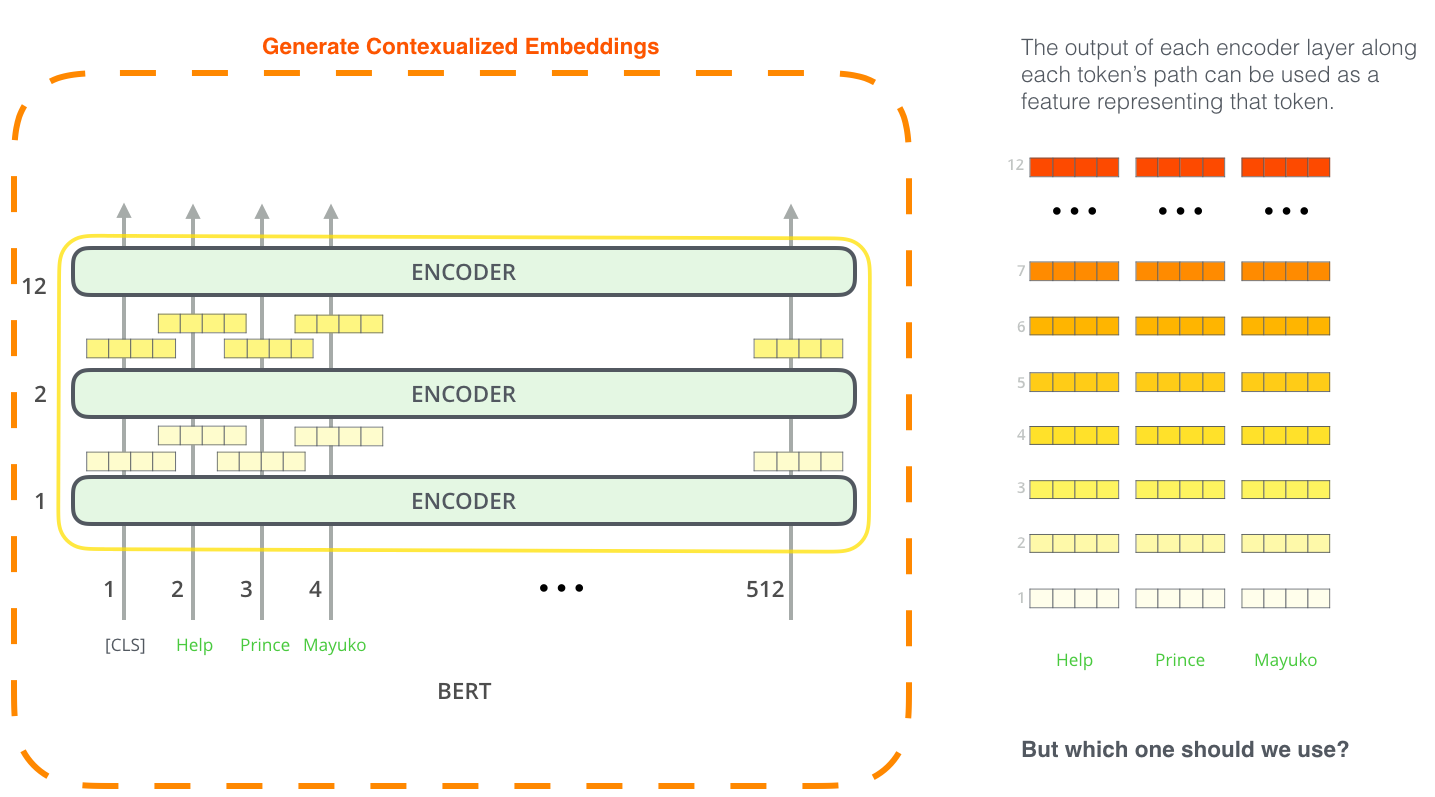
http://jalammar.github.io/illustrated-bert/

In [9]:
# Carrega o modelo pré-treinado
# Para acessar todos os estados ocultos (hidden states) é necessário configurar o parâmetro output_hidden_states = True
model = TFBertModel.from_pretrained(checkpoint, output_hidden_states = True)
# Aplica o modelo pré-treinado às sentenças de entrada
outputs = model(inputs)
# Exibe o formato do estado oculto da última camada de saída
print(outputs.last_hidden_state.shape)
# Os elementos também podem ser acessados por chave ou índice, como abaixo:
#print(outputs["last_hidden_state"].shape)
#print(outputs[0].shape) # The last hidden-state is the first element of the output tuple

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

(2, 9, 768)


No exemplo acima, temos:
- Batch size = 2: duas sentenças de entrada
- Sequence length = 9: comprimento das sequências de entrada (veja o tamanho das listas do vetor input_ids)
- Hidden size = 768: comprimento do vetor de saída para cada token de entrada. Cada saída contém o embedding de um dos 9 tokens de entrada.

In [10]:
# Hidden State de todas as 13 camadas
print("Hidden States: ", outputs["hidden_states"])
# Hidden State da camada de embedding
print("Hidden State 0: ", outputs["hidden_states"][0])
# Hidden State da primeira camada após a camada de embedding
print("Hidden State 1: ", outputs["hidden_states"][1])
# Hidden State da última camada (o mesmo que outputs["last_hidden_state"])
print("Hidden State 12: ", outputs["hidden_states"][12])
print("Last Hidden State: ", outputs["last_hidden_state"])
# Vetor de features da última camada (Hidden State 12) para o primeiro token (após o token CLS) da primeira sentença
print("Hidden State 12, Sentença 0, Token 1: ", outputs["hidden_states"][12][0][1])
print("Last Hidden State, Sentença 0, Token 1: ", outputs["last_hidden_state"][0][1])
# BERT pooler: vetor de features correspondente à representação do embedding do token CLS após processado por
# uma camada linear e uma função de ativação tanh.
# Ele pode ser usado como uma representação agregada de toda a sentença.
# Entretanto, o Hugging Face não recomenda a sua utilização por não obter bons resultados.
print("BERT pooler do Token CLS: ", outputs["pooler_output"])

Hidden States:  (<tf.Tensor: shape=(2, 9, 768), dtype=float32, numpy=
array([[[-0.38289848,  0.12982377, -0.15237722, ...,  0.28270787,
         -0.49243945, -0.02894129],
        [-1.0503334 , -0.1847419 ,  1.2997375 , ...,  0.92022264,
         -0.3219158 ,  0.0697578 ],
        [-0.07955045,  0.07359239, -0.23493364, ..., -1.3115    ,
          0.6789876 , -1.3100572 ],
        ...,
        [ 0.8086496 , -0.07814394,  0.13865855, ...,  1.0421146 ,
          0.7634177 ,  0.2584053 ],
        [ 0.67522424,  0.68051565,  0.0857626 , ...,  1.2011576 ,
          0.79959095,  0.29810613],
        [ 0.8526018 ,  0.42072836,  0.21475777, ...,  1.1991937 ,
          0.6796401 ,  0.34815094]],

       [[-0.38289848,  0.12982377, -0.15237722, ...,  0.28270787,
         -0.49243945, -0.02894129],
        [-0.89870596,  0.02781906,  1.5246282 , ...,  1.60486   ,
         -0.9391282 ,  0.38450617],
        [-0.07955045,  0.07359239, -0.23493364, ..., -1.3115    ,
          0.6789876 , -1.3100572 

### Extraindo os Embeddings

In [11]:
# Sentença com significados diferentes para a palavra "banco"
text = "Após ir ao banco pedir um empréstimo, Maria sentou-se no banco da praça."
inputs = tokenizer(text, padding=True, truncation=True, return_tensors="tf")
# Como já mostrado em código acima, o token id da palavra "banco" é o "55379".
# Esse token se encontra nas posições 4 e 19 do vetor de tokens de entrada
print("Entrada: ", tokenizer.decode(inputs['input_ids'][0]))
print("Tokens ids da entrada: ", inputs['input_ids'][0])
print("Token id da 1a palavra 'banco': ", inputs['input_ids'][0][4])
print("Token id da 2a palavra 'banco': ", inputs['input_ids'][0][19])
# Observe que os embeddings das duas palavras "banco" são diferentes, pois possuem contextos diferentes
outputs = model(inputs)
#print("Embedding de todos os tokens de entrada: ", outputs["last_hidden_state"][0])
print("Embedding da 1a palavra 'banco': ", outputs["last_hidden_state"][0][4])
print("Embedding da 2a palavra 'banco': ", outputs["last_hidden_state"][0][19])

Entrada:  [CLS] Após ir ao banco pedir um empréstimo, Maria sentou - se no banco da praça. [SEP]
Tokens ids da entrada:  tf.Tensor(
[  101 23906 10478 10610 55379 11161 11957 10293 10266 52302 27584 15487
   117 11066 14541 11010   118 10126 10192 55379 10143 69857 12989   119
   102], shape=(25,), dtype=int32)
Token id da 1a palavra 'banco':  tf.Tensor(55379, shape=(), dtype=int32)
Token id da 2a palavra 'banco':  tf.Tensor(55379, shape=(), dtype=int32)
Embedding da 1a palavra 'banco':  tf.Tensor(
[ 1.21365890e-01  1.35429427e-02  3.03406209e-01  4.22596186e-02
  1.51734501e-01  6.08378947e-01 -4.17286396e-01  4.67341632e-01
 -6.65868670e-02 -1.92265213e-01 -2.44157299e-01  5.16127884e-01
 -7.53886625e-02 -5.68460524e-01  2.36182153e-01  4.99788225e-01
  6.96122885e-01  5.53972542e-01 -3.32377583e-01 -3.51926148e-01
 -6.92571819e-01 -2.62875438e-01 -1.24744102e-01  4.89822894e-01
 -9.62030590e-02  7.07041442e-01 -7.77847290e-01 -3.83819878e-01
  3.48444164e-01  1.44755036e-01  2.94338

## Escolha da Camada / Estratégia de Pooling
Os autores do BERT avaliaram estratégias de word embedding por meio de diferentes combinações de vetores como features de entrada para uma BiLSTM usada para a tarefa de reconhecimento de entidades nomeadas, e obtiveram os resultados de F1 mostrados na figura abaixo.
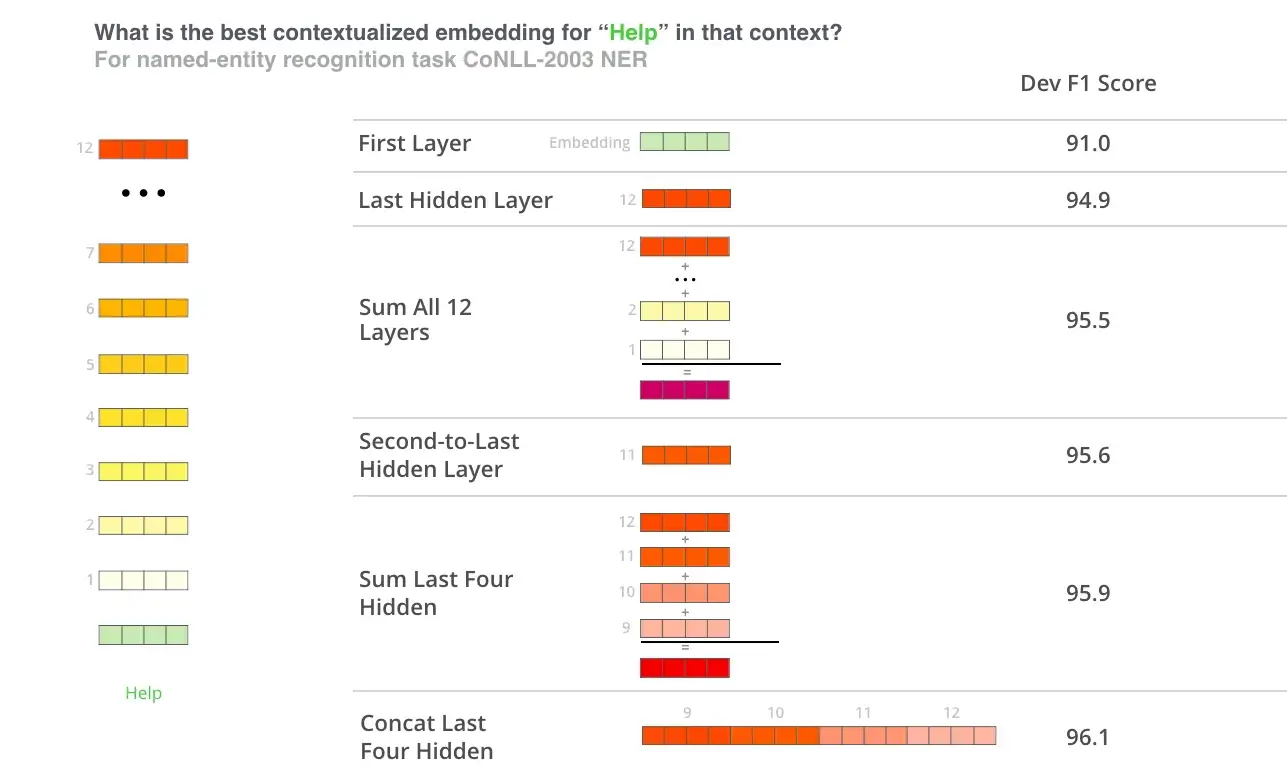
http://jalammar.github.io/illustrated-bert/

# Fim

Esses foram os passos para entendimento do funcionamento do Modelo BERT para geração de Word Embeddings.

-------------------------------------------